# FiCO₂ ⇌ PaCO₂ — a practical tutorial

**What this is.** A short, task-oriented guide to converting between the two ways a CO₂ challenge
gets reported: the **inspired fraction** (FiCO₂, e.g. “5% CO₂”) and the **arterial / end-tidal
partial pressure** (PaCO₂ ≈ P<sub>ET</sub>CO₂, in mmHg or kPa).

**Why it isn’t just a unit conversion.** Inspired CO₂ raises arterial CO₂, but the rise itself
stimulates ventilation, which blows off part of the extra CO₂. The two measures are therefore
related through the *hypercapnic ventilatory response* (HCVR), not by a fixed ratio.

> **This notebook does not re-derive the model.** The full derivation, the physiological
> assumptions, the provenance of every constant, and the validation live in the accompanying
> **technical note**. Here we just *use* the converter. Read the note first if you want to know
> *why*; read this if you want to know *how*.

---
### Contents
1. [Setup](#setup)
2. [The one equation](#eq)
3. [Forward: PaCO₂ → FiCO₂](#fwd)
4. [Reverse: FiCO₂ → PaCO₂](#rev)
5. [Reference table](#table)
6. [How much does the slope matter?](#slope)
7. [Short challenges: the time-dependent model](#time)
8. [Does it match real data?](#valid)
9. [When *not* to use this](#limits)
10. [Interactive prompt](#cli)
11. [Where the numbers come from](#prov)

<a id='setup'></a>
## 1. Setup

Everything lives in a single dependency-free module, `fico2_paco2_converter.py`.
(`numpy` / `matplotlib` are only needed for the figures.)

In [1]:
from fico2_paco2_converter import (
    params_from_baseline,      # you know the subject's resting PaCO2
    params_resting_default,    # you don't -> literature resting values
    paco2_to_fico2,            # forward:  PaCO2 -> FiCO2  (steady state)
    fico2_to_paco2,            # reverse:  FiCO2 -> PaCO2  (steady state)
    ParamsTimeDependent,       # time-dependent model (duration matters)
    fico2_to_paco2_timedep,    # reverse, with a challenge duration t
    mmhg_to_kpa, kpa_to_mmhg,
)

print('ready')

ready


<a id='eq'></a>
## 2. The one equation

Arterial CO₂ is what you breathe in, plus what your metabolism adds, divided by how hard you breathe:

$$P_aCO_2 \;=\; \underbrace{F_iCO_2\,(P_{atm}-P_{H_2O})}_{\text{what you breathe in}}
\;+\; \underbrace{\frac{K\,\dot V_{CO_2}}{\dot V_A(P_aCO_2)}}_{\text{what you make, divided by how hard you breathe}}$$

and ventilation itself responds to CO₂, approximately linearly over the working range (the HCVR, slope $S$):

$$\dot V_A(P_aCO_2) \;=\; \dot V_{A,\text{base}} \;+\; S\,(P_aCO_2 - P_aCO_{2,\text{base}})$$

Because $\dot V_A$ is linear in $P_aCO_2$, substituting it back makes the whole thing a **quadratic** in
$P_aCO_2$ — so both directions have exact closed-form solutions. No iteration needed. (These are Eqs. 11–15
of the technical note.)

| symbol | default | meaning |
|---|---|---|
| $S$ | 2.69 L·min⁻¹·mmHg⁻¹ | HCVR slope (Hirshman et al. 1975, n = 44; individuals span 1.00–5.95) |
| $\dot V_{CO_2}$ | 200 mL·min⁻¹ | CO₂ output (STPD) |
| $P_aCO_{2,\text{base}}$ | 40 mmHg | resting arterial CO₂ |
| $\dot V_{A,\text{base}}$ | 4.3 L·min⁻¹ | resting alveolar ventilation ($K\dot V_{CO_2}/P_aCO_{2,\text{base}}$) |
| $K$ | 0.863 | STPD→BTPS / fraction→pressure unit constant |
| $P_{atm}-P_{H_2O}$ | 713 mmHg | dry-gas pressure at sea level |

<a id='fwd'></a>
## 3. Forward — “I want a PaCO₂ of X. What FiCO₂ do I give?”

This is the common design question when planning a gas challenge. The HCVR fixes the ventilation at the
target PaCO₂, and FiCO₂ is whatever inspired tension is left over in the mass balance (note Eq. 13).

In [2]:
paco2_target = 50.0   # mmHg — the hypercapnic level you want
paco2_base   = 40.0   # mmHg — the subject's resting PaCO2

p = params_from_baseline(paco2_base)
fico2 = paco2_to_fico2(paco2_target, p)

print(f'To reach PaCO2 = {paco2_target:.1f} mmHg from a baseline of {paco2_base:.0f} mmHg,')
print(f'  give FiCO2 = {fico2:.2f} %')
print(f'  (ventilation at target: {p.VA(paco2_target):.1f} L/min, up from {p.VA_base:.1f} at rest)')

To reach PaCO2 = 50.0 mmHg from a baseline of 40 mmHg,
  give FiCO2 = 6.24 %
  (ventilation at target: 31.2 L/min, up from 4.3 at rest)


<a id='rev'></a>
## 4. Reverse — “The paper says 5% CO₂. What PaCO₂ was that?”

This is the common question when *reading* the literature, and the reason the converter exists:
it puts challenges reported as `%` and challenges reported as `mmHg` onto one scale. The converter
returns the exact **physical (upper) root** of the quadratic (note Eq. 15); the lower root falls below
the apnoeic threshold and is discarded.

In [3]:
for fi in (3, 5, 7):
    pa = fico2_to_paco2(fi, p)
    print(f'FiCO2 {fi:>2}%  ->  PaCO2 = {pa:5.1f} mmHg = {mmhg_to_kpa(pa):.2f} kPa'
          f'   ({pa - p.PaCO2_base:+.1f} mmHg from baseline)')

FiCO2  3%  ->  PaCO2 =  41.6 mmHg = 5.54 kPa   (+1.6 mmHg from baseline)
FiCO2  5%  ->  PaCO2 =  45.1 mmHg = 6.02 kPa   (+5.1 mmHg from baseline)
FiCO2  7%  ->  PaCO2 =  54.0 mmHg = 7.20 kPa   (+14.0 mmHg from baseline)


### If you don’t know the subject’s baseline

Most papers don’t report it. Use the literature resting fallback
(PaCO₂ = 40 mmHg, $\dot V_A$ = 4.3 L·min⁻¹). The two are essentially self-consistent, and the
ventilatory feedback absorbs the tiny difference — FiCO₂ = 0 still returns ≈ 40.0 mmHg.

In [4]:
p_default = params_resting_default()
print(f'baseline unknown -> VA_base = {p_default.VA_base:.1f} L/min')
print(f'  sanity check: FiCO2 0% -> PaCO2 = {fico2_to_paco2(0.0, p_default):.2f} mmHg  (should be ~40)')
print(f'  FiCO2 5%      -> PaCO2 = {fico2_to_paco2(5.0, p_default):.2f} mmHg')

baseline unknown -> VA_base = 4.3 L/min
  sanity check: FiCO2 0% -> PaCO2 = 40.01 mmHg  (should be ~40)
  FiCO2 5%      -> PaCO2 = 45.15 mmHg


<a id='table'></a>
## 5. Reference table

Steady-state conversion at sea level, baseline 40 mmHg, S = 2.69 — this reproduces Table 2 of the
technical note. Handy for reading papers.

In [5]:
print(f"{'FiCO2 %':>8} {'PICO2 mmHg':>11} {'PaCO2 mmHg':>11} {'PaCO2 kPa':>10}")
print('-' * 44)
for fi in (0, 2, 3, 4, 5, 6, 7, 8):
    pa = fico2_to_paco2(fi, p)
    print(f'{fi:8.0f} {fi/100*p.Pdry:11.1f} {pa:11.1f} {mmhg_to_kpa(pa):10.2f}')

 FiCO2 %  PICO2 mmHg  PaCO2 mmHg  PaCO2 kPa
--------------------------------------------
       0         0.0        40.0       5.33
       2        14.3        40.8       5.44
       3        21.4        41.6       5.54
       4        28.5        42.9       5.72
       5        35.6        45.1       6.02
       6        42.8        48.9       6.52
       7        49.9        54.0       7.20
       8        57.0        60.0       8.00


<a id='slope'></a>
## 6. How much does the slope matter?

**A lot — it is the single biggest source of uncertainty.** $S$ is a *population mean*. Hirshman
et al. (1975) measured 44 healthy adults: mean 2.69, but individuals ranged from **1.00 to 5.95**.

So treat the output as a population-level estimate, not a prediction for one person.

In [6]:
print(f"{'S':>6} {'PaCO2 (5% CO2)':>16}")
print('-' * 24)
for S in (1.00, 2.69, 5.95):
    ps = params_from_baseline(40.0, S=S)
    print(f'{S:6.2f} {fico2_to_paco2(5.0, ps):16.1f}')
print('\n-> a 5% challenge could mean anything from ~43 to ~49 mmHg, depending on the subject.')

     S   PaCO2 (5% CO2)
------------------------
  1.00             48.8
  2.69             45.1
  5.95             43.1

-> a 5% challenge could mean anything from ~43 to ~49 mmHg, depending on the subject.


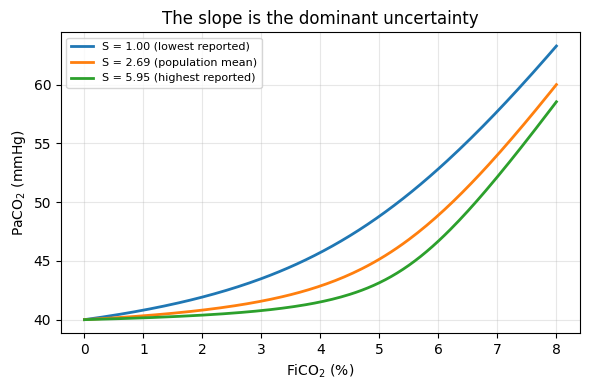

In [7]:
import numpy as np, matplotlib.pyplot as plt

grid = np.linspace(0, 8, 161)
plt.figure(figsize=(6, 4))
for S, lab in [(1.00, 'S = 1.00 (lowest reported)'),
               (2.69, 'S = 2.69 (population mean)'),
               (5.95, 'S = 5.95 (highest reported)')]:
    ps = params_from_baseline(40.0, S=S)
    plt.plot(grid, [fico2_to_paco2(f, ps) for f in grid], lw=2, label=lab)
plt.xlabel('FiCO$_2$ (%)'); plt.ylabel('PaCO$_2$ (mmHg)')
plt.title('The slope is the dominant uncertainty')
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

<a id='time'></a>
## 7. Short challenges: the time-dependent model

Everything above assumes the ventilatory response has **fully developed**. It hasn’t, in the first
few minutes. Ventilation ramps up with a fast (carotid-body) and a slow (central) component, so
early in a challenge less CO₂ is being blown off and **the true PaCO₂ is transiently higher**.

The time-dependent model adds exactly one variable — the duration $t$ — by scaling the slope
(note Eqs. 17–19):

$$\phi(t) = \lambda\,(1-e^{-t/\tau_1}) + (1-\lambda)\,(1-e^{-t/\tau_2}), \qquad S_{\text{eff}}(t) = \phi(t)\cdot S$$

with $\tau_1$ = 9.7 s, $\tau_2$ = 132 s, $\lambda$ = 0.295 (subject-weighted means of Swanson & Bellville
1975, Ward & Bellville 1983, Bellville et al. 1979, Dahan et al. 1990 and Berkenbosch et al. 1992 — see §11).

**It is the same model with a smaller slope.** Nothing else changes. Two limits are worth knowing:
at $t\to\infty$, $\phi\to1$ and it becomes the steady-state model; at $t\to0$, $\phi\to0$, ventilation
stays at baseline, and PaCO₂ takes its largest, feedback-free value $P_iCO_2 + P_aCO_{2,\text{base}}$.

In [8]:
pt = ParamsTimeDependent()

print('Effective slope as the response develops (steady-state S = 2.69):')
for t in (1e-6, 10, 30, 60, 120, 300, 600, None):
    lab = 'steady' if t is None else ('t->0' if t < 1 else f'{t:>4.0f} s')
    print(f'  t = {lab:>6}:  phi = {pt.phi(t):.3f}  ->  S_eff = {pt.S_eff(t):.2f}')

print('\nPaCO2 during a fixed 7% challenge (transiently higher early, settles to steady state):')
for t in (10, 60, 300, 600, None):
    lab = 'steady' if t is None else f'{t:>4} s'
    print(f'  t = {lab}:  PaCO2 = {fico2_to_paco2_timedep(7, pt, t_s=t):.1f} mmHg')

# t -> 0 non-compensable maximum: PaCO2 = PICO2 + baseline
pico2_7 = 0.07 * pt.Pdry
print(f'\n  non-compensable limit (t->0):  PaCO2 = PICO2 + baseline = '
      f'{pico2_7:.1f} + {pt.PaCO2_base:.0f} = {pico2_7 + pt.PaCO2_base:.1f} mmHg')

Effective slope as the response develops (steady-state S = 2.69):
  t =   t->0:  phi = 0.000  ->  S_eff = 0.00
  t =   10 s:  phi = 0.241  ->  S_eff = 0.65
  t =   30 s:  phi = 0.425  ->  S_eff = 1.14
  t =   60 s:  phi = 0.552  ->  S_eff = 1.48
  t =  120 s:  phi = 0.716  ->  S_eff = 1.92
  t =  300 s:  phi = 0.927  ->  S_eff = 2.49
  t =  600 s:  phi = 0.992  ->  S_eff = 2.67
  t = steady:  phi = 1.000  ->  S_eff = 2.69

PaCO2 during a fixed 7% challenge (transiently higher early, settles to steady state):
  t =   10 s:  PaCO2 = 59.9 mmHg
  t =   60 s:  PaCO2 = 56.0 mmHg
  t =  300 s:  PaCO2 = 54.2 mmHg
  t =  600 s:  PaCO2 = 54.0 mmHg
  t = steady:  PaCO2 = 54.0 mmHg

  non-compensable limit (t->0):  PaCO2 = PICO2 + baseline = 49.9 + 40 = 89.9 mmHg


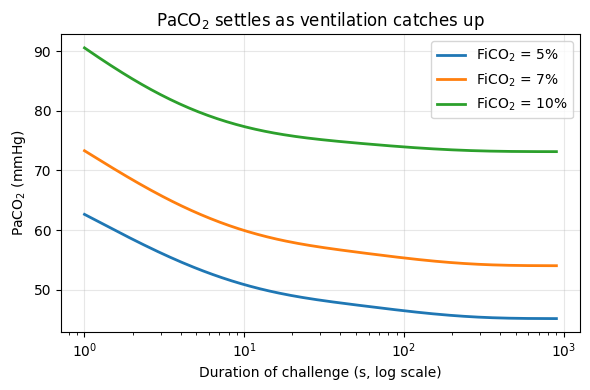

In [9]:
ts = np.logspace(0, np.log10(900), 200)
plt.figure(figsize=(6, 4))
for fi in (5, 7, 10):
    plt.plot(ts, [fico2_to_paco2_timedep(fi, pt, t_s=t) for t in ts], lw=2, label=f'FiCO$_2$ = {fi}%')
plt.xscale('log')
plt.xlabel('Duration of challenge (s, log scale)'); plt.ylabel('PaCO$_2$ (mmHg)')
plt.title('PaCO$_2$ settles as ventilation catches up')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

**Rule of thumb.** By ~5 min the difference is small; by ~10 min it has essentially vanished
($S_{\text{eff}} \approx S$). So for a challenge held for tens of minutes — which is most BOLD-MRI and
CVR protocols — the **steady-state model is enough**. Reach for the time-dependent model only for
short or transient challenges.

<a id='valid'></a>
## 8. Does it match real data?

A compact version of the note’s validation (Figure 4c, Supplementary Table S2): **eight human
studies that delivered a fixed 5% inspired CO₂** and reported end-tidal CO₂. We feed each study’s own
baseline into the steady-state converter and compare the prediction with what was measured.

In [10]:
import math

# study, baseline PETCO2 (mmHg), measured PETCO2 (mmHg)  -- all fixed 5% inspired CO2
studies = [
    ('Xu et al. 2011',            41.3, 50.1),
    ('Deckers 2022 (CO2-in-air)', 45.0, 49.2),
    ('Deckers 2022 (carbogen)',   43.7, 48.1),
    ('Rodgers 2015 (T2)',         38.5, 50.1),
    ('Rodgers 2015 (suscept.)',   38.5, 50.1),
    ('Peng et al. 2017 (pt 1)',   40.0, 48.0),
    ('Peng et al. 2017 (pt 2)',   40.0, 48.0),
    ('Thesen et al. 2012',        40.0, 48.0),
]

print(f"{'study':26} {'base':>5} {'meas':>6} {'pred':>6} {'meas-pred':>10}")
print('-' * 57)
resid = []
for name, base, meas in studies:
    pred = fico2_to_paco2(5.0, params_from_baseline(base))   # steady-state, study's own baseline
    resid.append(meas - pred)
    print(f'{name:26} {base:5.1f} {meas:6.1f} {pred:6.1f} {meas - pred:+10.1f}')

n    = len(resid)
rmse = math.sqrt(sum(r * r for r in resid) / n)
bias = -sum(resid) / n            # predicted - observed
print('-' * 57)
print(f'RMSE = {rmse:.1f} mmHg,  bias (predicted - observed) = {bias:+.1f} mmHg   (n = {n})')

study                       base   meas   pred  meas-pred
---------------------------------------------------------
Xu et al. 2011              41.3   50.1   46.0       +4.1
Deckers 2022 (CO2-in-air)   45.0   49.2   48.5       +0.7
Deckers 2022 (carbogen)     43.7   48.1   47.6       +0.5
Rodgers 2015 (T2)           38.5   50.1   44.3       +5.8
Rodgers 2015 (suscept.)     38.5   50.1   44.3       +5.8
Peng et al. 2017 (pt 1)     40.0   48.0   45.1       +2.9
Peng et al. 2017 (pt 2)     40.0   48.0   45.1       +2.9
Thesen et al. 2012          40.0   48.0   45.1       +2.9
---------------------------------------------------------
RMSE = 3.7 mmHg,  bias (predicted - observed) = -3.2 mmHg   (n = 8)


The model lands within about **3–4 mmHg** of the reported values (RMSE ≈ 3.7 mmHg), with a **systematic
~3 mmHg under-prediction** — it reads slightly low. Part of that is expected: every study here measured
*end-tidal* CO₂, which runs a few mmHg below arterial in healthy lungs, and the population-mean slope
will not match any single cohort. Because all eight challenges were **sustained (≥ ~4 min, so
$\phi\approx0.9$)**, the time-dependent prediction is within a few tenths of a mmHg of the steady-state
one — this comparison therefore tests the *steady-state* relationship, exactly as the note states.
Use it as evidence the framework gets the **order of magnitude** right, not as a per-subject predictor.

<a id='limits'></a>
## 9. When *not* to use this

Being honest about the bounds is more useful than the converter itself:

- **Above PaCO₂ ≈ 80 mmHg.** The linear HCVR is a local approximation and cannot be extrapolated
  indefinitely; at high inspired CO₂ the ventilatory response becomes nonlinear and is eventually
  replaced by respiratory depression and systemic toxicity (Lambertsen 1971; Permentier et al. 2017).
  Above this cap, use a *measured* PaCO₂.
- **Anaesthetised subjects.** Anaesthesia blunts the slope and shifts the operating point. Substitute
  agent- and depth-appropriate parameters; don’t use the awake default 2.69 (note §6).
- **Animals.** Mass-specific metabolic rate, resting ventilation and CO₂ sensitivity differ between
  species. The *form* of the equation holds, but every constant must be re-parameterised — you cannot
  rescale human values.
- **Diseased lungs.** The model assumes PaCO₂ ≈ P<sub>A</sub>CO₂ ≈ P<sub>ET</sub>CO₂. Appreciable
  V̇/Q̇ mismatch or shunt breaks that.
- **Any individual subject.** $S$ spans 1.00–5.95 between people. This is a population tool for
  *harmonising reported challenges across studies*, not a bedside predictor.

<a id='cli'></a>
## 10. Interactive prompt

The same thing as a guided prompt (also available as `python fico2_paco2_converter.py -i`).
It asks for the model (steady-state or time-dependent), then the direction.

In [11]:
from fico2_paco2_converter import interactive
interactive()

 FiCO2 <-> PaCO2 converter
 Which model?
   S) steady-state    -- response fully developed; closed form (default S=2.69)
   T) time-dependent  -- you also give the challenge DURATION; uses S_eff(t)=phi(t)*S
  Please type S or T.
# time-dependent: at t = 0.69 min, phi = 0.480 -> S_eff = 1.29 L/min/mmHg (steady-state S = 2.69)

 What do you know / want?
   1) I have a target PaCO2  ->  estimate FiCO2
   2) I have an inspired FiCO2  ->  estimate PaCO2

-- Estimate PaCO2 from a given FiCO2 --

  FiCO2 = 10.000 %  (PICO2 = 71.3 mmHg)
  effective slope S_eff = 1.29 L/min/mmHg ;  VA = 51.88 L/min
  ->  PaCO2 = 74.63 mmHg = 9.949 kPa  (rise of +36.63 mmHg from baseline)


<a id='prov'></a>
## 11. Where the numbers come from

Every constant traces to a **human** study. No value is assumed or invented.

| parameter | value | source |
|---|---|---|
| $S$ | 2.69 L·min⁻¹·mmHg⁻¹ (range 1.00–5.95) | Hirshman et al. 1975 — 44 healthy adults, rebreathing |
| $\dot V_{A,\text{base}}$ | 4.3 L·min⁻¹ | self-consistent ($K\dot V_{CO_2}/P_aCO_2$ = 4.315); within West & Luks 2021 range |
| $\dot V_{CO_2}$ | 200 mL·min⁻¹ STPD | Lumb & Thomas 2020 |
| $K$ | 0.863 | Cruickshank & Hirschauer 2004 |

**Time constants** — the **five** studies that report both, in normoxic/euoxic humans:

| study | n | $\tau_1$ (fast) | $\tau_2$ (slow) | $\lambda$ |
|---|---|---|---|---|
| Swanson & Bellville 1975 | 1 | 17.5 s | 75 s | ~0.50 |
| Ward & Bellville 1983 | 6 | 5.7 s | 72 s | 0.29 |
| Bellville et al. 1979 | 7 | 14.8 ± 11.1 s | 180.1 ± 96.0 s | 0.34 |
| Dahan et al. 1990 | 9 | 9.8 ± 3.5 s | 146.6 ± 48.8 s | 0.30 |
| Berkenbosch et al. 1992 | 10 | 7.6 s | 127.5 s | 0.26 |
| **subject-weighted mean (adopted)** | **33** | **9.7 s** | **132 s** | **0.295** |

The time constants $\tau_1,\tau_2$ are subject-weighted over all five studies (n = 33); $\lambda$ is the
mean over the **four** studies that report both chemoreflex gains (n = 32) — Swanson & Bellville’s
$\lambda\approx0.50$ is a single-subject estimate and is excluded from the mean. All five lie inside the
8–26 s and 65–180 s ranges summarised by Tansley et al. (1998), and the source studies applied end-tidal
steps of **+7 to +11 mmHg** — equivalent to ≈ **5–7% inspired CO₂** by the steady-state conversion above.

---
*Full derivation, assumptions, and validation against **29 reported challenge conditions** (of which the
8 fixed-5% human observations in §8 form the quantitative set): see the technical note.*